## Sprint 3 - Analisis exploratorio de datos

### Analisis de datos abiertos (movilidad)

In [1]:
# Importar librerias necesarias para analisis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### validacion_SITP

In [2]:
# 1. Cargar el dataset de validaciones
df_sitp = pd.read_csv('../datos_limpios/validacion_SITP.csv')

In [3]:
# 2. Agrupar los datos: Contar cuantas validaciones hay por cada acceso en cada estacion
agrupado = df_sitp.groupby(['estacion_parada', 'acceso_estacion']).size().reset_index(name='cantidad')
# Ordenar de mayor a menor para que el grafico sea mas fácil de leer
agrupado = agrupado.sort_values(by='cantidad', ascending=False)

#### Visualizar variables

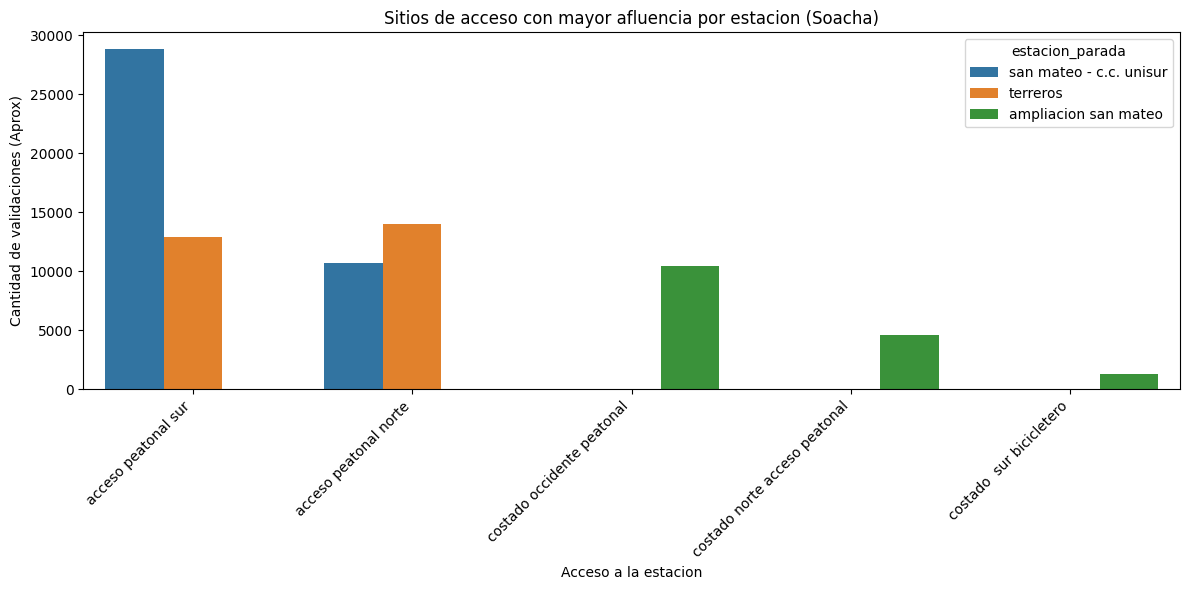

In [4]:
# 5. Crear el grafico con Seaborn y Matplotlib
plt.figure(figsize=(12, 6)) # Tamaño de la figura
sns.barplot(data=agrupado, x='acceso_estacion', y='cantidad', hue='estacion_parada')

# 6. Personalizar títulos y etiquetas
plt.title('Sitios de acceso con mayor afluencia por estacion (Soacha)')
plt.xticks(rotation=45, ha='right') # Rotar el texto del eje X para que no se superponga
plt.ylabel('Cantidad de validaciones (Aprox)')
plt.xlabel('Acceso a la estacion')
plt.tight_layout() # Ajustar los márgenes automáticamente

# 7. Mostrar el gráfico (o guardarlo si usas plt.savefig('nombre.png'))
plt.show()

### Promedios tiempo y desplazamiento

In [5]:
# 1. Cargar el dataset de tiempos promedio
df_tiempo = pd.read_csv('../datos_limpios/Tiempo_promedio.csv')
df_velocidad = pd.read_csv('../datos_limpios/Velocidad_promedio.csv')

In [6]:
# 2. Unificar las columnas para tener un solo marco de datos historico completo
# En Velocidad_promedio, la columna 'tiempo' equivale a los minutos para recorrer 10km 
df_vel_subset = df_velocidad[['ano', 'velocidad_promedio_km/h', 'tiempo']].rename(
    columns={'velocidad_promedio_km/h': 'velocidad_kmh', 'tiempo': 'minutos_10km'}
)

# En Tiempo_promedio, renombramos para que coincidan
df_tiempo_subset = df_tiempo[['ano', 'velocidad_km/h', 'minutos_en_10_kilometros_recorridos']].rename(
    columns={'velocidad_km/h': 'velocidad_kmh', 'minutos_en_10_kilometros_recorridos': 'minutos_10km'}
)

# Unimos todo en un solo DataFrame historico
df_historico_completo = pd.concat([df_vel_subset, df_tiempo_subset], ignore_index=True)

In [7]:
# 3. Calcular promedios historicos (2002 - 2025)
promedio_vel_historica = df_historico_completo['velocidad_kmh'].mean()
promedio_tiempo_historico = df_historico_completo['minutos_10km'].mean()

In [8]:
# 4. Calcular promedios Recientes (2022 - 2025) usando solo el dataset de Tiempo_promedio
promedio_vel_reciente = df_tiempo_subset['velocidad_kmh'].mean()
promedio_tiempo_reciente = df_tiempo_subset['minutos_10km'].mean()

In [9]:
# 5. Validacion de la hipotesis (60 a 90 minutos) con datos recientes
# Regla de 3: (Minutos de viaje / Minutos que toma hacer 10km) * 10 km
distancia_60_min = (60 / promedio_tiempo_reciente) * 10
distancia_90_min = (90 / promedio_tiempo_reciente) * 10

In [10]:
# 6. Imprimir los resultados
print("--- PROMEDIOS HISTORICOS (2002-2025) ---")
print(f"Velocidad promedio historica: {promedio_vel_historica:.2f} km/h")
print(f"Tiempo promedio para 10 km histórico: {promedio_tiempo_historico:.2f} minutos\n")

print("--- PROMEDIOS RECIENTES (2022-2025) ---")
print(f"Velocidad promedio actual: {promedio_vel_reciente:.2f} km/h")
print(f"Tiempo promedio para 10 km actual: {promedio_tiempo_reciente:.2f} minutos\n")

print("--- Hipotesis - Tiempos de recorrido en bogota ---")
print(f"Distancia recorrida en 60 min a velocidad actual: {distancia_60_min:.2f} km")
print(f"Distancia recorrida en 90 min a velocidad actual: {distancia_90_min:.2f} km")

--- PROMEDIOS HISTORICOS (2002-2025) ---
Velocidad promedio historica: 21.06 km/h
Tiempo promedio para 10 km histórico: 29.45 minutos

--- PROMEDIOS RECIENTES (2022-2025) ---
Velocidad promedio actual: 16.57 km/h
Tiempo promedio para 10 km actual: 36.33 minutos

--- Hipotesis - Tiempos de recorrido en bogota ---
Distancia recorrida en 60 min a velocidad actual: 16.52 km
Distancia recorrida en 90 min a velocidad actual: 24.78 km


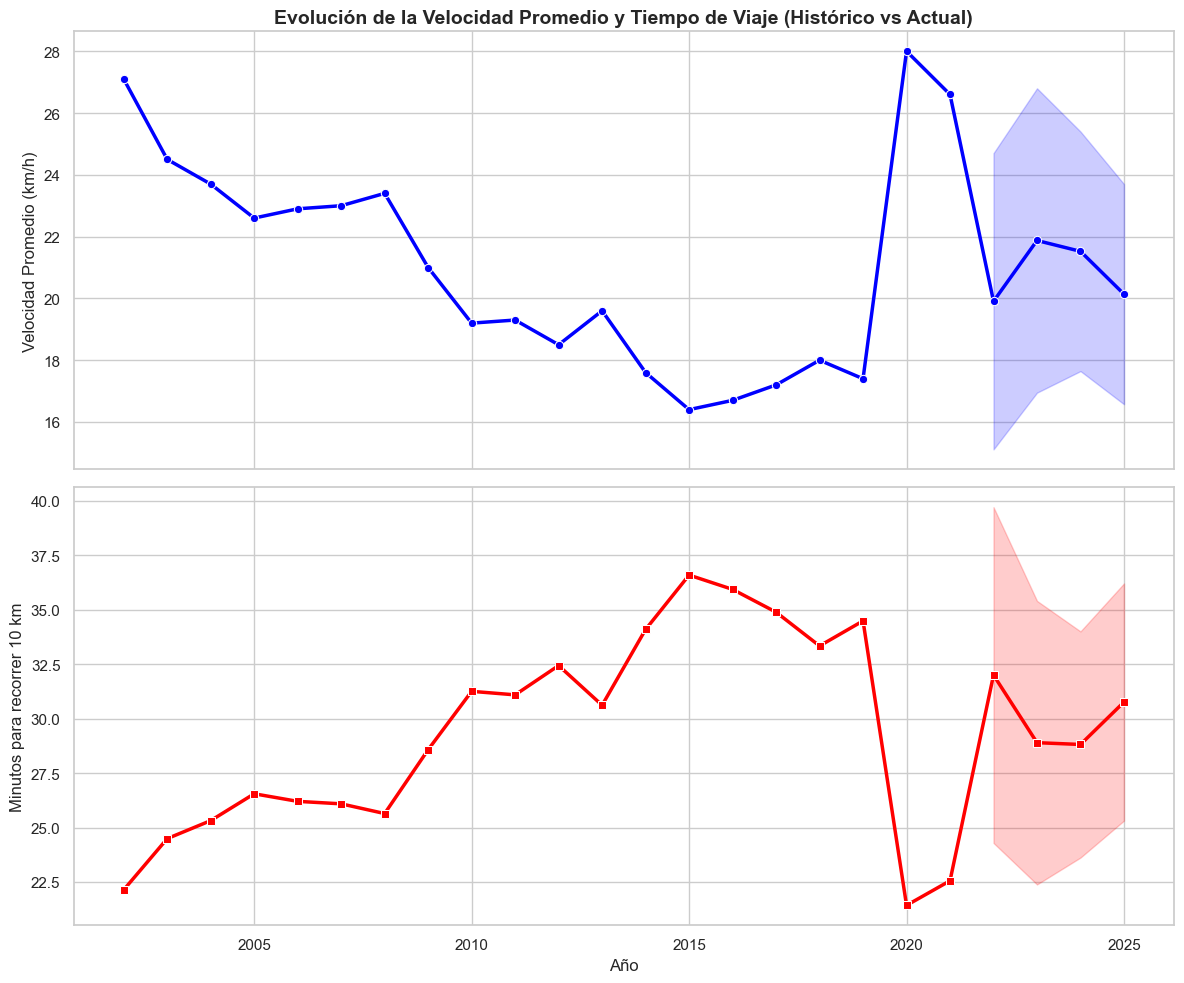

In [11]:
# 3. Configurar la visualizacin
sns.set_theme(style="whitegrid") # Estilo con cuadricula de fondo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True) # generar dos graficos, uno arriba del otro

#Linea 1: Velocidad
sns.lineplot(data=df_historico_completo, x='ano', y='velocidad_kmh', marker='o', ax=ax1, color='blue', linewidth=2.5)
ax1.set_title('Evolución de la Velocidad Promedio y Tiempo de Viaje (Histórico vs Actual)', fontsize=14, weight='bold')
ax1.set_ylabel('Velocidad Promedio (km/h)', fontsize=12)

# Linea 2: Tiempo de viaje
sns.lineplot(data=df_historico_completo, x='ano', y='minutos_10km', marker='s', ax=ax2, color='red', linewidth=2.5)
ax2.set_ylabel('Minutos para recorrer 10 km', fontsize=12)
ax2.set_xlabel('Año', fontsize=12)

# Ajustar el diseño para que no se superpongan los textos
plt.tight_layout()

# Mostrar el grafico
plt.show()

### Analisis datos encuesta universidad

In [16]:
# Importar librerias necesarias para el analisis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [17]:
# 1. Cargar dataset de encuesta 
df_universidad = pd.read_csv('../datos_limpios/Datos_universidad.csv')
df_velocidad = pd.read_csv('../datos_limpios/Velocidad_promedio.csv')
df_tiempo = pd.read_csv('../datos_limpios/Tiempo_promedio.csv')

# limpieza basica para que no existan errores
df_universidad['tiempo_llegada'] = df_universidad['tiempo_llegada'].replace({'Mas de 120 min': 'mas de 120 min'})
df_universidad['promedio_academico'] = df_universidad['promedio_academico'].replace({'4.6 a 5': '4.6 a 5.0'})

In [18]:
# 2. seleccionamos variables clave para el analisis (Feature Selection)
columnas_clave = [
    'medio_transporte', 'tiempo_llegada', 'trasbordos', 
    'jornada', 'promedio_academico', 'afecta_rendimiento'
]
df_analisis = df_universidad[columnas_clave]

--- ANALISIS DE PATRONES Y METRICAS CLAVE ---

In [23]:
# 3. patron 1: El impacto general (% de afectacion)

# Calcula las frecuencias relativas (porcentajes) de cada categoria en la columna 'afecta_rendimiento'
afectacion = df_analisis['afecta_rendimiento'].value_counts(normalize=True) * 100
# Suma los porcentajes de impacto positivo ("si" y "a veces").
afectacion_total = afectacion.get('si', 0) + afectacion.get('a veces', 0) # Se usa .get() con un 0 por defecto para evitar errores en caso de que alguna respuesta no exista en los datos
print(f"\n1. IMPACTO GENERAL:")
# Muestra el resultado final interpolando la variable afectacion_total, limitando los decimales a uno (.1f)
print(f"El {afectacion_total:.1f}% de los estudiantes reporta que el viaje afecta su rendimiento (Si o a veces).")


1. IMPACTO GENERAL:
El 92.0% de los estudiantes reporta que el viaje afecta su rendimiento (Si o a veces).


In [24]:
# 4. patron 2: Movilidad en el sistema masivo (transporte publico) vs micro movilidad
print("\n2. TIEMPOS POR MEDIO DE TRANSPORTE:")

# Filtramos TransMilenio
tm_usuarios = df_analisis[df_analisis['medio_transporte'].str.contains('transmilenio', case=False, na=False)]
# calculamos el porcentaje de personas que tienen un tiempo de llegada mayor a 60 min
tm_tiempos_altos = tm_usuarios['tiempo_llegada'].isin(['61-90 min', '91-120 min', 'mas de 120 min']).mean() * 100

# Filtramos micromovilidad (Bici/Moto)
micro_usuarios = df_analisis[df_analisis['medio_transporte'].str.contains('bicicleta|moto', case=False, na=False)]
# calculamos el porcentaje de personas que tienen un tiempo de llegada menor a 60 min
micro_tiempos_bajos = micro_usuarios['tiempo_llegada'].isin(['0-30 min', '30-60 min']).mean() * 100

print(f"Usuarios de TransMilenio con viajes mayores a 60 min: {tm_tiempos_altos:.1f}%")
print(f"Usuarios de Moto/Bici con viajes menores a 60 min: {micro_tiempos_bajos:.1f}%")



2. TIEMPOS POR MEDIO DE TRANSPORTE:
Usuarios de TransMilenio con viajes mayores a 60 min: 100.0%
Usuarios de Moto/Bici con viajes menores a 60 min: 100.0%


In [21]:
# 5. patron 3: Correlacion Tiempo - Universidad
print("\n3. DISTRIBUCION DE PROMEDIOS (Viajes Cortos vs Viajes Largos):")
# Filtra el DataFrame original para crear un subconjunto solo con estudiantes que viajan menos de 1 hora
viajes_cortos = df_analisis[df_analisis['tiempo_llegada'].isin(['0-30 min', '30-60 min'])]
# Filtra el DataFrame original para crear un subconjunto con estudiantes que viajan más de 1.5 horas
viajes_largos = df_analisis[df_analisis['tiempo_llegada'].isin(['91-120 min', 'mas de 120 min'])]

# Evalua que estudiantes del grupo "cortos" tienen un promedio de '4.1 a 4.5' (genera una serie de True/False)
# Al aplicar .mean(), calcula la proporcion de 'True', y se multiplica por 100 para sacar el porcentaje.
excelencia_cortos = (viajes_cortos['promedio_academico'] == '4.1 a 4.5').mean() * 100
# Aplica la misma logica estadistica pero para el grupo de viajes largos
excelencia_largos = (viajes_largos['promedio_academico'] == '4.1 a 4.5').mean() * 100

# Muestra los resultados en pantalla, limitando los porcentajes a un solo decimal (.1f)
print(f"Porcentaje de buenas notas (4.1 a 4.5) en viajes de menos de 1 hora: {excelencia_cortos:.1f}%")
print(f"Porcentaje de buenas notas (4.1 a 4.5) en viajes de más de 1.5 horas: {excelencia_largos:.1f}%")



3. DISTRIBUCION DE PROMEDIOS (Viajes Cortos vs Viajes Largos):
Porcentaje de buenas notas (4.1 a 4.5) en viajes de menos de 1 hora: 56.8%
Porcentaje de buenas notas (4.1 a 4.5) en viajes de más de 1.5 horas: 33.3%


In [26]:
# 6. Patron 4: Contexto de movilidad en la ciudad Bogota
print("\n4. CONTEXTO URBANO (Data de Ciudad):")
# Filtra df_velocidad para el año 2002, selecciona la columna 'velocidad_promedio_km/h'
# y usa .values[0] para extraer el numero exacto, dejando de lado el formato de Serie de Pandas.
vel_2002 = df_velocidad[df_velocidad['ano'] == 2002]['velocidad_promedio_km/h'].values[0]
# Realiza el mismo proceso para el año 2025, pero extrayendo el dato del DataFrame df_tiempo
vel_2025 = df_tiempo[df_tiempo['ano'] == 2025]['velocidad_km/h'].values[0]
# Calcula la variacion porcentual usando la formula: ((Valor Final - Valor Inicial) / Valor Inicial) * 100
caida_vel = ((vel_2025 - vel_2002) / vel_2002) * 100

# Imprime los resultados en pantalla. Los valores de 2025 y la caida porcentual 
# se formatean a un solo decimal (.1f) para una lectura mas limpia
print(f"Velocidad en 2002: {vel_2002} km/h")
print(f"Velocidad en 2025: {vel_2025:.1f} km/h")
print(f"Caída historica del rendimiento vial: {caida_vel:.1f}%")


4. CONTEXTO URBANO (Data de Ciudad):
Velocidad en 2002: 27.1 km/h
Velocidad en 2025: 16.6 km/h
Caída historica del rendimiento vial: -38.8%


### Visualizacion graficas 

In [25]:
# 1. Definir el orden natural de las categorias de tiempo y notas para que las graficas tengan logica
orden_tiempo = ['0-30 min', '30-60 min', '61-90 min', '91-120 min', 'mas de 120 min']
orden_promedio = ['3.0 a 3.5', '3.6 a 4.0', '4.1 a 4.5', '4.6 a 5.0']

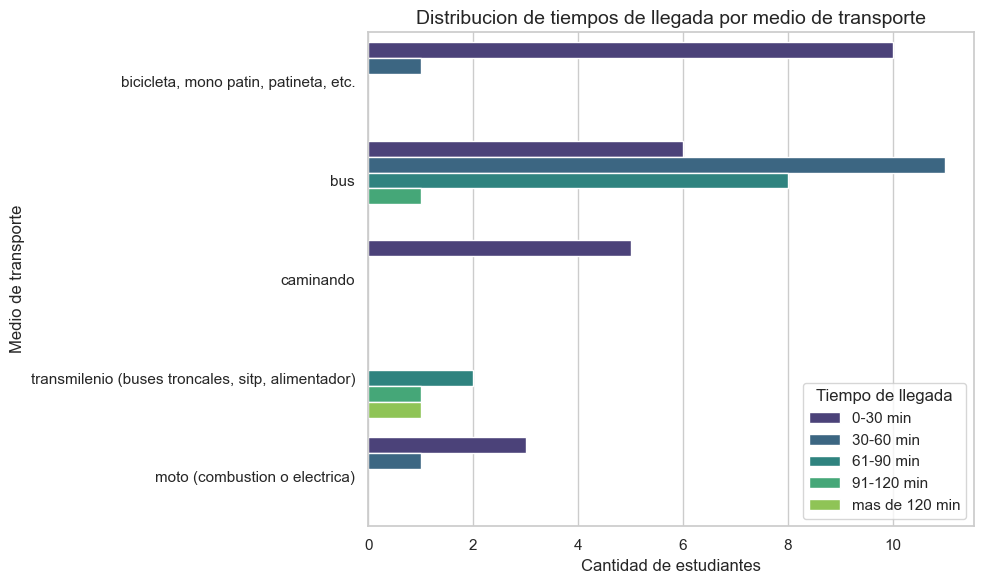

In [28]:
# GRAFICA 1: Tiempos de llegada por Medio de Transporte
plt.figure(figsize=(10, 6))

# Crea un grafico de barras horizontal (countplot).
# - data: el DataFrame a utilizar
# - y: coloca 'medio_transporte' en el eje vertical (hace que las barras sean horizontales)
# - hue: divide/agrupa cada barra principal segun el 'tiempo_llegada'
# - hue_order: respeta un orden logico prestablecido para las categorias de tiempo
# - palette: aplica la paleta de colores 'viridis' (agradable a la vista y accesible para daltonismo)
sns.countplot(data=df_universidad, y='medio_transporte', hue='tiempo_llegada', hue_order=orden_tiempo, palette='viridis')
# Agrega un titulo principal a la grafica y define el tamaño de la fuente
plt.title('Distribucion de tiempos de llegada por medio de transporte', fontsize=14)
# Etiqueta el eje X (horizontal)
plt.xlabel('Cantidad de estudiantes')
# Etiqueta el eje Y (vertical)
plt.ylabel('Medio de transporte')
# Configura la leyenda indicando su titulo y forzando su ubicacion en la esquina inferior derecha ('lower right')
plt.legend(title='Tiempo de llegada', loc='lower right')
# Ajusta automaticamente los margenes para asegurar que ningun texto, titulo o eje quede recortado
plt.tight_layout()
# Renderiza y muestra la grafica final en pantalla
plt.show()

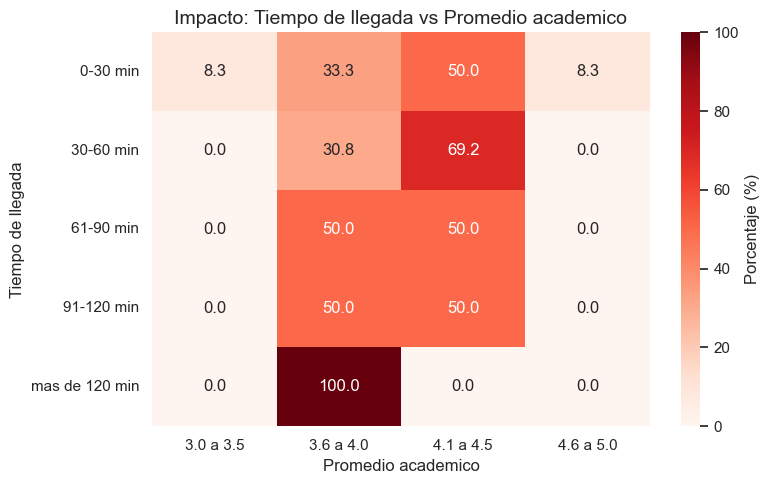

In [29]:
# GRAFICA 2: mapa de calor (Tiempo vs Promedio)
# Se cruzan las dos variables categoricas y se sacan porcentajes
# El parametro normalize='index' calcula los porcentajes por cada fila (cada tiempo de llegada suma 100%), y multiplicamos por 100 para convertir la proporcion decimal a porcentaje
heatmap_data = pd.crosstab(df_universidad['tiempo_llegada'], df_universidad['promedio_academico'], normalize='index') * 100
# Reordena las filas y columnas usando las listas prestablecidas (orden_tiempo y orden_promedio) para que sigan una progresion logica, Si queda algun espacio vacio (NaN), lo rellena con 0
heatmap_data = heatmap_data.reindex(index=orden_tiempo, columns=orden_promedio).fillna(0)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Porcentaje (%)'})
plt.title('Impacto: Tiempo de llegada vs Promedio academico', fontsize=14)
plt.xlabel('Promedio academico')
plt.ylabel('Tiempo de llegada')
plt.tight_layout()
plt.show()

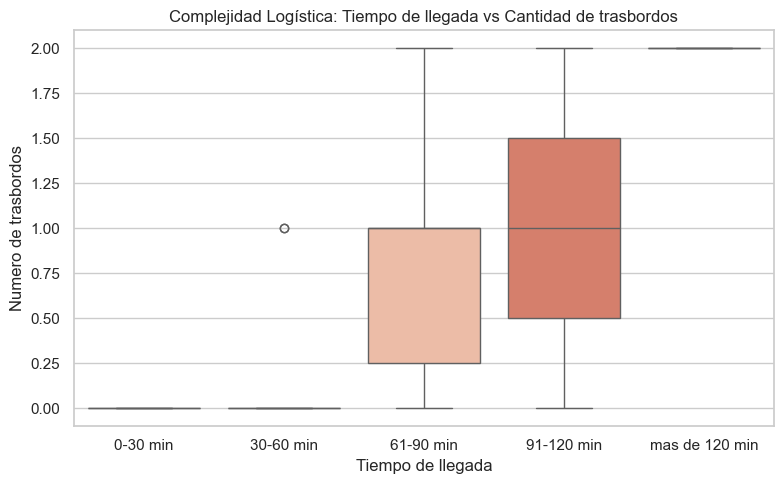

In [30]:
# GRAFICA 4: Tiempos de Llegada vs Numero de trasbordos
plt.figure(figsize=(8,5))
# Genera un diagrama de caja (boxplot) para visualizar la distribucion estadistica.
# - x='tiempo_llegada', y='trasbordos': Cruza las categorias de tiempo con la cantidad numerica de trasbordos.
# - order=orden_tiempo: Mantiene la secuencia logica de los tiempos en el eje X.
# - palette='coolwarm': Usa un degradado de colores de frio a calido.
# - hue='tiempo_llegada' y legend=False: Un truco moderno de Seaborn para aplicar la paleta 
#   correctamente a cada barra en el eje X sin generar una leyenda redundante.
sns.boxplot(data=df_universidad, x='tiempo_llegada', y='trasbordos', order=orden_tiempo, palette='coolwarm', hue='tiempo_llegada', legend=False)
plt.title('Complejidad Logística: Tiempo de llegada vs Cantidad de trasbordos')
plt.xlabel('Tiempo de llegada')
plt.ylabel('Numero de trasbordos')
plt.tight_layout()
plt.show()